# Demo 1 — Spontaneous activity (1-D ring)

A near-critical recurrent network turns unstructured noisy input into structured
*spontaneous* activity: the recurrent connectivity amplifies its own preferred
spatial modes. Here we compare that spontaneous activity across connectivity
profiles on a 1-D ring — Mexican hat, GRF-modulated Mexican hat, shuffled
Mexican hat, random, and an E/I network.

All plots are shown inline; nothing is saved.

In [1]:
# --- make the package importable ---------------------------------------------
# The package files live flat in this repository folder (itself named
# "cortical_rate_model"), so we add the PARENT directory to the path.
import sys, pathlib
_cwd = pathlib.Path.cwd()
_parent = _cwd.parent if _cwd.name == "cortical_rate_model" else _cwd
sys.path.insert(0, str(_parent))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import cortical_rate_model as crm
from cortical_rate_model import Layout, RateNetwork, EIRateNetwork, make_connectivity, inputs, plotting
print("cortical_rate_model", crm.__version__)

cortical_rate_model 0.1.0


In [2]:
def build_net(kind, layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Single-population network with its recurrent gain set by spectral radius."""
    W = make_connectivity(kind, layout, **params)
    W = crm.scale_spectral_radius(W, spectral_radius)
    return RateNetwork(W, layout=layout, nonlinearity=nonlinearity)

def build_ei(layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Two-population E/I network with its recurrent gain set by spectral radius."""
    W, meta = make_connectivity("ei_homogeneous", layout, normalise="spectral",
                                spectral_radius=spectral_radius, **params)
    return EIRateNetwork(W, meta=meta, layout=layout, nonlinearity=nonlinearity)

## Setup

A ring of 100 units driven by band-pass spatial noise around a baseline
(`inputs.noisy_background`). We generate several independent noise realisations
and read out each steady state.

In [3]:
ring = Layout(100, periodic=True)
n_patterns = 24
spont_drive = inputs.noisy_background(ring, noise_level=0.5, baseline=1.0,
                                      n_patterns=n_patterns, sigma1=1.0, seed=1)
print("spontaneous drive shape (patterns, units):", spont_drive.shape)

profiles = {
    "mexican_hat":          dict(sigma=6.0, inh_factor=2.0),
    "grf_mexican_hat":      dict(sigma=6.0, inh_factor=2.0, grf_strength=0.6),
    "shuffled_mexican_hat": dict(sigma=6.0, inh_factor=2.0, fraction=0.3),
    "random":               dict(g=1.0),
}

spontaneous drive shape (patterns, units): (24, 100)


## Spontaneous patterns per profile

Each panel shows the stack of spontaneous activity patterns (rows = noise
realisations, columns = position on the ring). The Mexican-hat networks organise
the noise into a few periodic modes; the random network stays comparatively
unstructured.

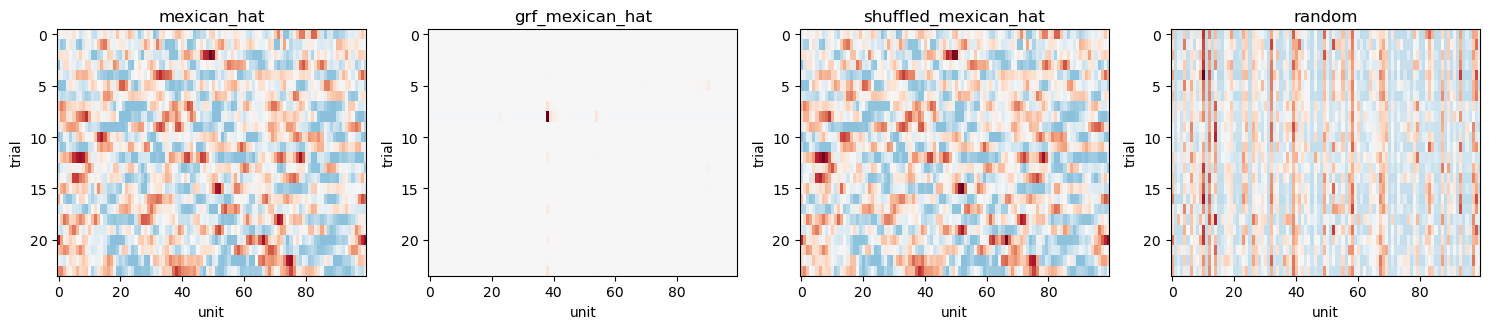

In [4]:
fig, axes = plt.subplots(1, len(profiles), figsize=(15, 3.4))
for ax, (kind, params) in zip(axes, profiles.items()):
    net = build_net(kind, ring, **params)
    resp = net.response(spont_drive, n_steps=300)          # (patterns, units)
    resp = resp - resp.mean(axis=1, keepdims=True)          # show the spatial pattern
    im = ax.imshow(resp, aspect="auto", cmap="RdBu_r",
                   vmin=-np.abs(resp).max(), vmax=np.abs(resp).max())
    ax.set_title(kind); ax.set_xlabel("unit"); ax.set_ylabel("trial")
plt.tight_layout(); plt.show()

## A few example traces (Mexican hat)

The individual spontaneous patterns are smooth, periodic bumps whose wavelength
is set by the Mexican-hat width.

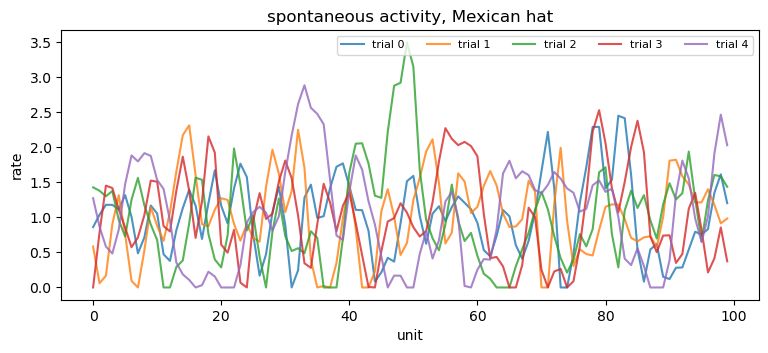

In [5]:
net = build_net("mexican_hat", ring, sigma=6.0, inh_factor=2.0)
resp = net.response(spont_drive, n_steps=300)
plt.figure(figsize=(9, 3.5))
for i in range(5):
    plt.plot(resp[i], alpha=0.8, label=f"trial {i}")
plt.xlabel("unit"); plt.ylabel("rate"); plt.title("spontaneous activity, Mexican hat")
plt.legend(ncol=5, fontsize=8); plt.show()

## E/I network

Noise is injected into the excitatory population; we read out the excitatory
spontaneous activity.

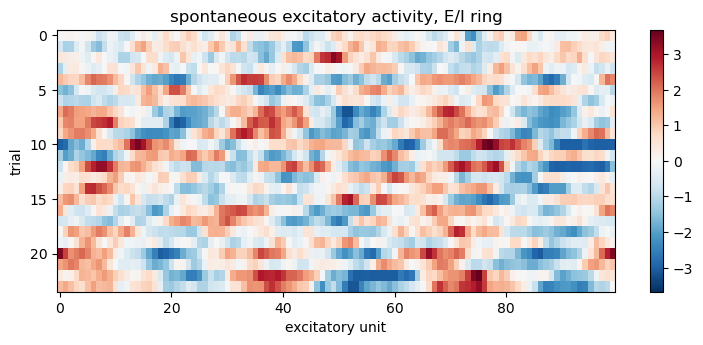

In [6]:
ei = build_ei(ring, sigma_ee=6.0, sigma_ei=12.0, sigma_ie=6.0, sigma_ii=12.0)
drive_ei = inputs.to_ei_input(exc_input=spont_drive, num_units=ring.num_units)
r = ei.response(drive_ei, n_steps=400)
r_exc, _ = ei.split_activity(r)
r_exc = r_exc - r_exc.mean(axis=1, keepdims=True)

plt.figure(figsize=(9, 3.4))
plt.imshow(r_exc, aspect="auto", cmap="RdBu_r",
           vmin=-np.abs(r_exc).max(), vmax=np.abs(r_exc).max())
plt.xlabel("excitatory unit"); plt.ylabel("trial")
plt.title("spontaneous excitatory activity, E/I ring"); plt.colorbar(); plt.show()